In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df=pd.read_csv("titanic_cleaned.csv")
sns.set_theme(style="whitegrid")
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STONO2 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,WC 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C


Question 1: What percentage of passengers survived? Create an appropriate chart. Write your observation.

Percentage breakdown:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64



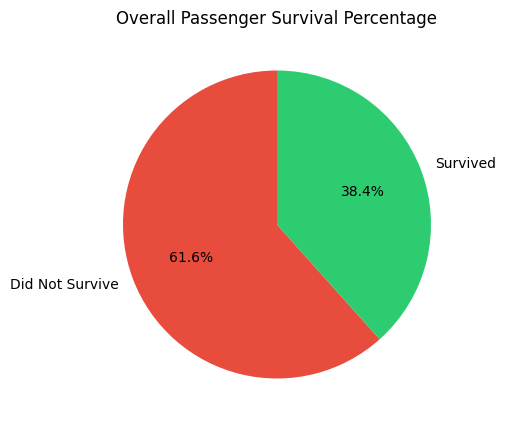

In [5]:
# Calculate exact percentages
survival_pct = df['Survived'].value_counts(normalize=True) * 100
print(f"Percentage breakdown:\n{survival_pct}\n")

# Visualization: Pie Chart or Count Plot
plt.figure(figsize=(6, 5))
plt.pie(df['Survived'].value_counts(), labels=['Did Not Survive', 'Survived'], 
        autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
plt.title('Overall Passenger Survival Percentage')
plt.show()

Question 2: Which gender had the highest survival rate? Create a visualization. Explain your findings.

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


C:\Users\zakma\AppData\Local\Temp\ipykernel_18704\1352601749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', palette='Set2', errorbar=None)


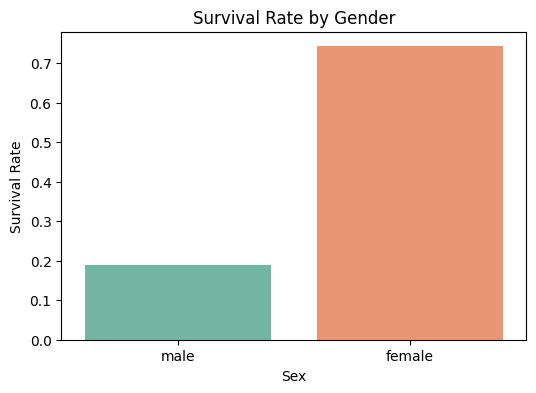

In [8]:
# Calculate survival rate by gender
print(df.groupby('Sex')['Survived'].mean() * 100)

# Visualization: Bar Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Sex', y='Survived', palette='Set2', errorbar=None)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

Question 3: Which passenger class had the highest survival rate? Support your answer with a chart.


C:\Users\zakma\AppData\Local\Temp\ipykernel_18704\1504617236.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='Blues_r', errorbar=None)


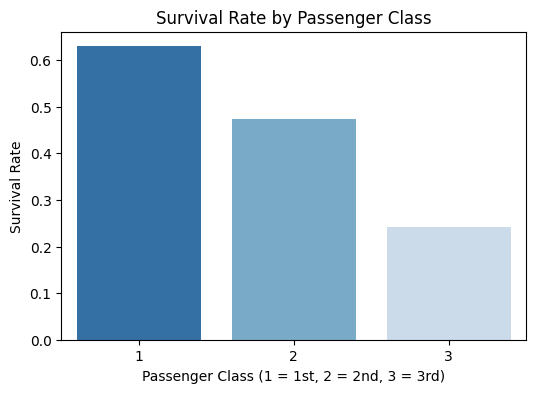

In [9]:
# Visualization: Bar Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Pclass', y='Survived', palette='Blues_r', errorbar=None)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Survival Rate')
plt.show()

Question 4: Does age affect survival? Use an appropriate visualization. Explain your conclusion.

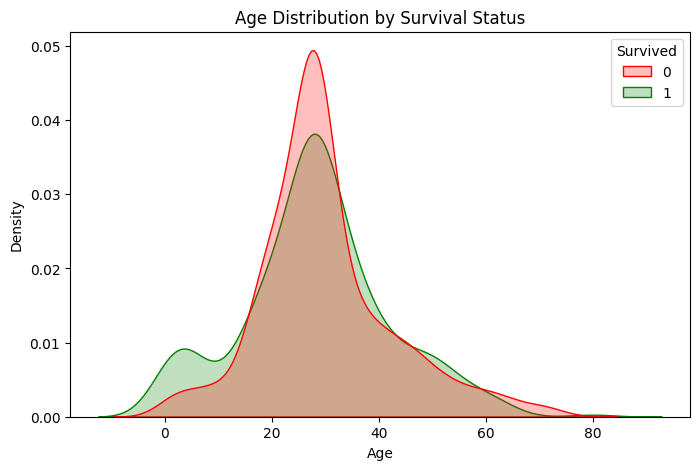

In [10]:
# Visualization: KDE Distribution / Histogram overlay
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Age', hue='Survived', common_norm=False, fill=True, palette={0: 'red', 1: 'green'})
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

Question 5: Does fare influence survival? Support your answer with visualization.

C:\Users\zakma\AppData\Local\Temp\ipykernel_18704\1517005385.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


ValueError: The palette dictionary is missing keys: {'1', '0'}

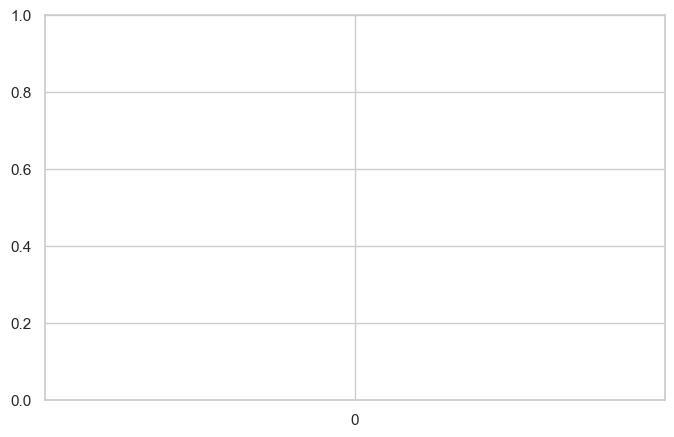

In [24]:
# Question 5: Does fare influence survival?
plt.figure(figsize=(8, 5))

# Use integer keys (0 and 1) in the palette dictionary
sns.boxplot(
    data=df, 
    x='Survived', 
    y='Fare', 
    palette={0: 'red', 1: 'green'}
)

plt.title('Fare Paid vs Survival Status')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.yscale('log')  # Log scale handles extreme fare outliers cleanly
plt.show()

Question 6: Did passengers travelling alone survive more often? Use a visualization. Explain your observation.

C:\Users\zakma\AppData\Local\Temp\ipykernel_18704\3884461148.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Is_Alone', y='Survived', palette='Set1', errorbar=None)


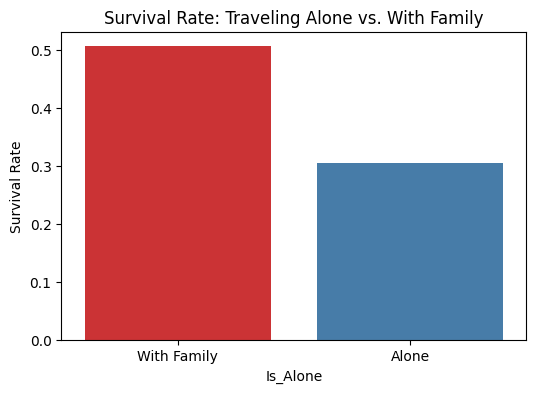

In [12]:
# Create Is_Alone feature if not present in your dataset
if 'Is_Alone' not in df.columns:
    if 'SibSp' in df.columns and 'Parch' in df.columns:
        df['Is_Alone'] = (df['SibSp'] + df['Parch'] == 0).astype(int)

# Visualization: Bar Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Is_Alone', y='Survived', palette='Set1', errorbar=None)
plt.title('Survival Rate: Traveling Alone vs. With Family')
plt.xticks([0, 1], ['With Family', 'Alone'])
plt.ylabel('Survival Rate')
plt.show()

Question 7: Which embarkation port had the highest survival rate? Create a chart and explain the result.

C:\Users\zakma\AppData\Local\Temp\ipykernel_18704\2177079367.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Embarked', y='Survived', palette='viridis', errorbar=None)


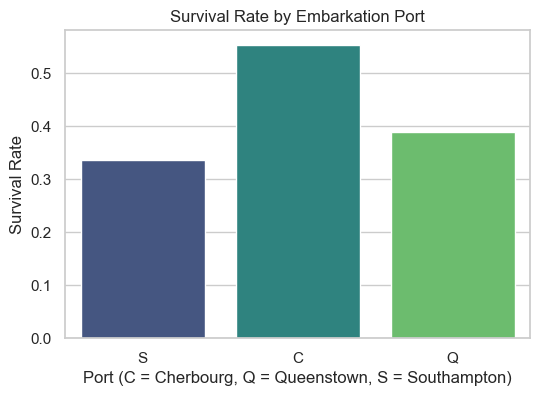

In [17]:
# Visualization: Bar Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Embarked', y='Survived', palette='viridis', errorbar=None)
plt.title('Survival Rate by Embarkation Port')
plt.xlabel('Port (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Survival Rate')
plt.show()

Question 8: What is the relationship between passenger class and fare? Support your answer using an appropriate visualization.

C:\Users\zakma\AppData\Local\Temp\ipykernel_18704\1074744573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='coolwarm')


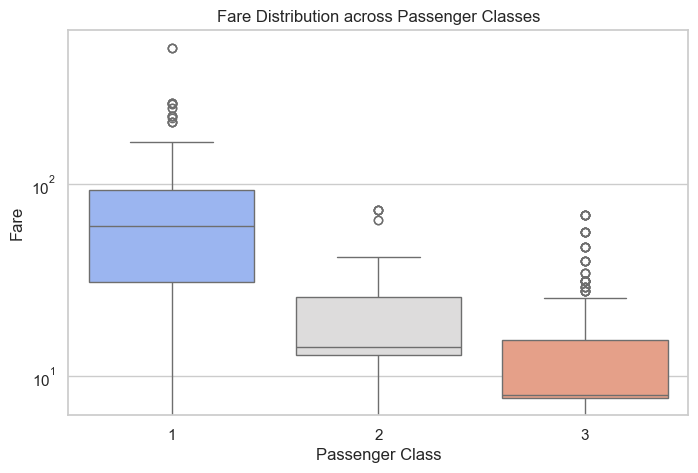

In [18]:
# Visualization: Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Pclass', y='Fare', palette='coolwarm')
plt.title('Fare Distribution across Passenger Classes')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.yscale('log')
plt.show()

Question 9: Create a Correlation Heatmap. Explain: strongest positive correlation, strongest negative correlation, and any interesting observations.

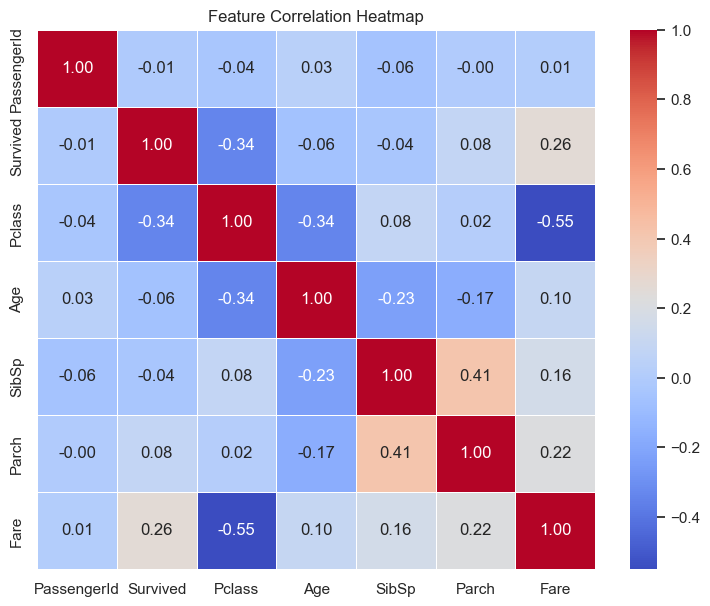

In [19]:
# Select numeric columns only for correlation matrix
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


Question 10: Custom Analysis — Family Size vs. Survival Rate

Survival Rate by Family Size:
             count  Survival_Rate
Family_Size                      
1              537       0.303538
2              161       0.552795
3              102       0.578431
4               29       0.724138
5               15       0.200000
6               22       0.136364
7               12       0.333333
8                6       0.000000
11               7       0.000000


C:\Users\zakma\AppData\Local\Temp\ipykernel_18704\224573255.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Family_Size', y='Survived', palette='magma', errorbar=None)


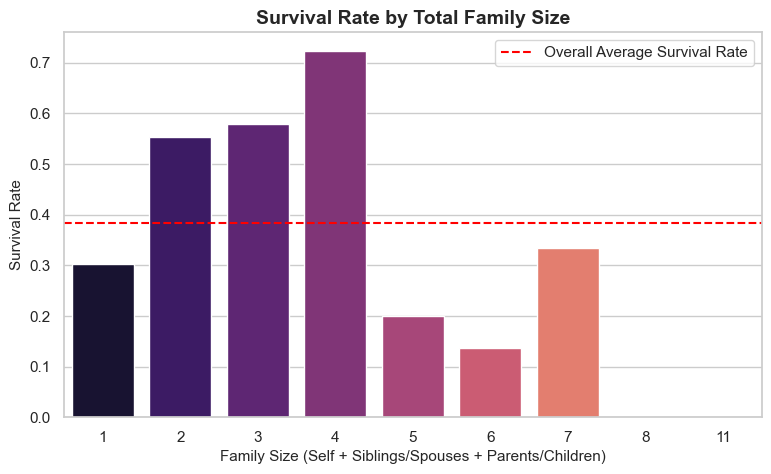

In [20]:
# 1. Feature Engineering: Calculate total Family Size (including the passenger)
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

# 2. Display summary statistics for Family Size
print("Survival Rate by Family Size:")
print(df.groupby('Family_Size')['Survived'].agg(['count', 'mean']).rename(columns={'mean': 'Survival_Rate'}))

# 3. Visualization: Bar plot of Family Size vs. Survival Rate
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='Family_Size', y='Survived', palette='magma', errorbar=None)
plt.title('Survival Rate by Total Family Size', fontsize=14, fontweight='bold')
plt.xlabel('Family Size (Self + Siblings/Spouses + Parents/Children)', fontsize=11)
plt.ylabel('Survival Rate', fontsize=11)
plt.axhline(df['Survived'].mean(), color='red', linestyle='--', label='Overall Average Survival Rate')
plt.legend()
plt.show()

# Statistical Analysis

In [21]:
# Select 3 numerical columns
selected_cols = ['Age', 'Fare', 'SibSp']

# Calculate statistics
stats_df = pd.DataFrame({
    'Mean': df[selected_cols].mean(),
    'Median': df[selected_cols].median(),
    'Mode': df[selected_cols].mode().iloc[0],
    'Std Dev': df[selected_cols].std()
})

print(stats_df)

            Mean  Median   Mode    Std Dev
Age    29.361582   28.00  28.00  13.019697
Fare   32.204366   14.45   8.05  49.693414
SibSp   0.523008    0.00   0.00   1.102743


# DASHBOARD

C:\Users\zakma\AppData\Local\Temp\ipykernel_18704\2086159025.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], data=df, x='Survived', palette=['#e74c3c', '#2ecc71'])
C:\Users\zakma\AppData\Local\Temp\ipykernel_18704\2086159025.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Did Not Survive', 'Survived'])
C:\Users\zakma\AppData\Local\Temp\ipykernel_18704\2086159025.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 1], data=df, x='Sex', palette='Set2')
C:\Users\zakma\AppData\Local\Temp\ipykernel_18704\2086159025.py:20: FutureWarning: 

Passi

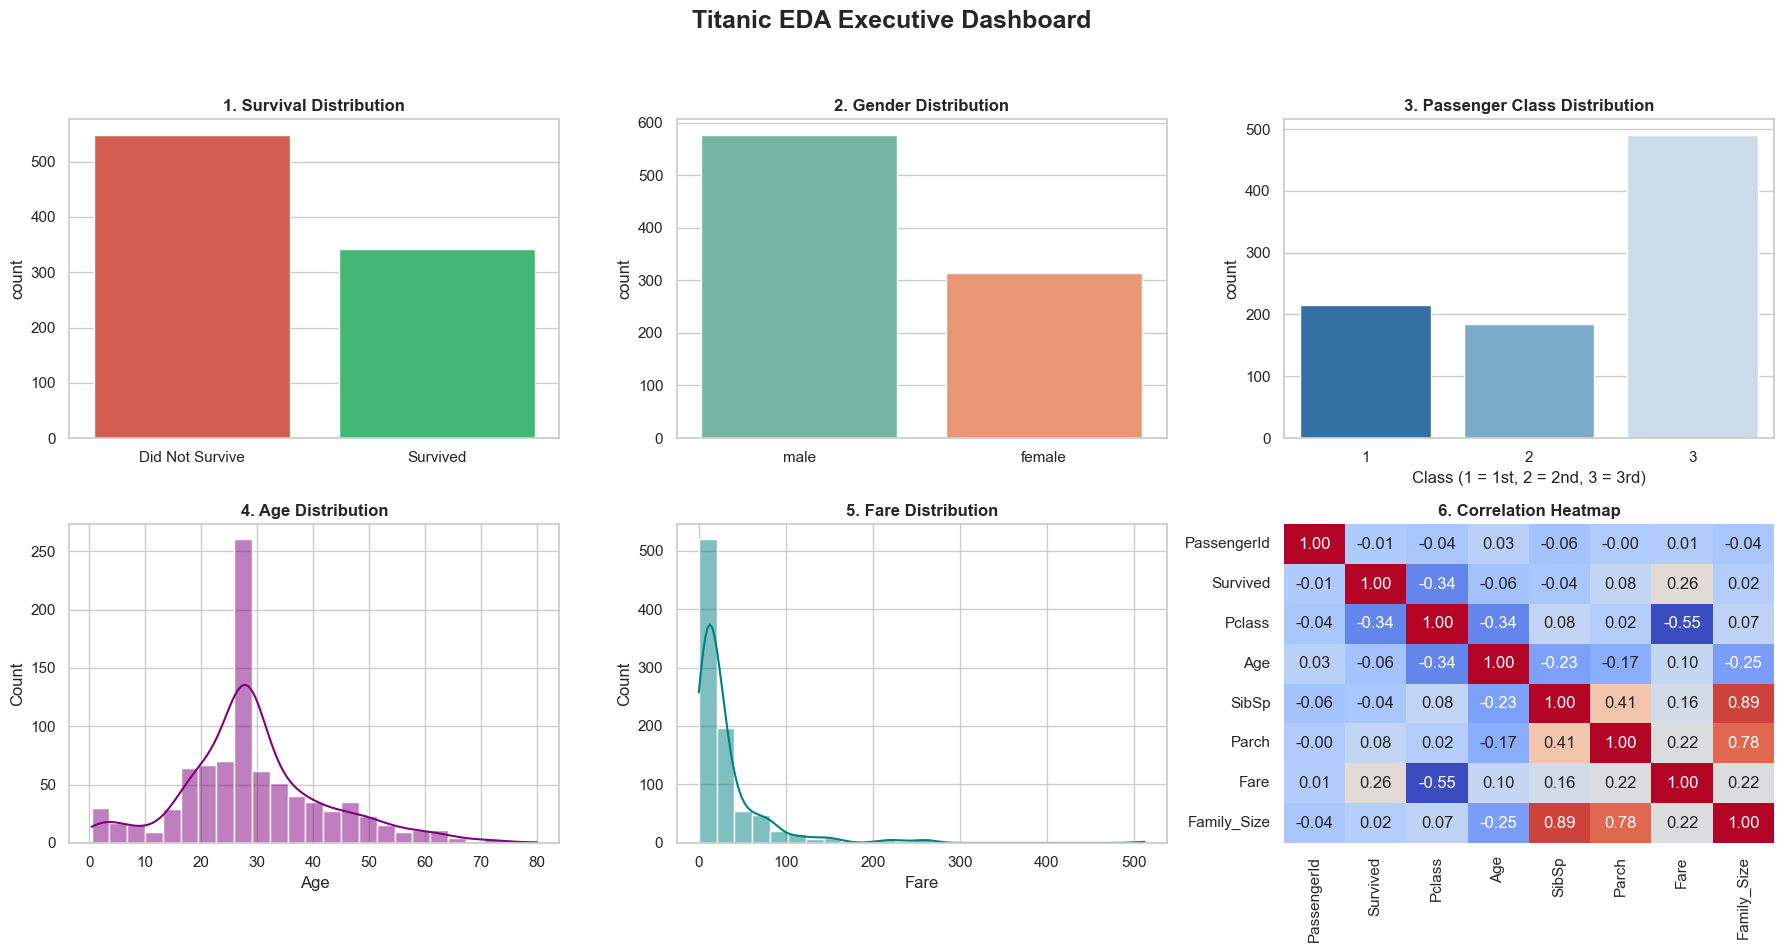

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a 2x3 subplot grid layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Titanic EDA Executive Dashboard', fontsize=18, fontweight='bold')

# 1. Survival Distribution
sns.countplot(ax=axes[0, 0], data=df, x='Survived', palette=['#e74c3c', '#2ecc71'])
axes[0, 0].set_title('1. Survival Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xticklabels(['Did Not Survive', 'Survived'])
axes[0, 0].set_xlabel('')

# 2. Gender Distribution
sns.countplot(ax=axes[0, 1], data=df, x='Sex', palette='Set2')
axes[0, 1].set_title('2. Gender Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('')

# 3. Passenger Class Distribution
sns.countplot(ax=axes[0, 2], data=df, x='Pclass', palette='Blues_r')
axes[0, 2].set_title('3. Passenger Class Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Class (1 = 1st, 2 = 2nd, 3 = 3rd)')

# 4. Age Distribution
sns.histplot(ax=axes[1, 0], data=df, x='Age', kde=True, color='purple', bins=25)
axes[1, 0].set_title('4. Age Distribution', fontsize=12, fontweight='bold')

# 5. Fare Distribution
sns.histplot(ax=axes[1, 1], data=df, x='Fare', kde=True, color='teal', bins=25)
axes[1, 1].set_title('5. Fare Distribution', fontsize=12, fontweight='bold')

# 6. Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(ax=axes[1, 2], data=numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
axes[1, 2].set_title('6. Correlation Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()